In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank/notebooks")

os.makedirs("results/figures", exist_ok=True)
print("Working dir:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank/notebooks


In [8]:
!pip install datasets matplotlib pillow -q

In [10]:
from datasets import load_dataset

# DocVQA — document images + questions + answers, modern format, no scripts
# perfect for our benchmark — ground truth text is built in
ds = load_dataset("lmms-lab/DocVQA", "DocVQA", split="validation[:300]", trust_remote_code=True)

print(ds.features)
print("\nFirst sample keys:", ds[0].keys())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lmms-lab/DocVQA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lmms-lab/DocVQA' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/2.69k [00:00<?, ?B/s]

DocVQA/validation-00000-of-00006.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

DocVQA/validation-00001-of-00006.parquet:   0%|          | 0.00/160M [00:00<?, ?B/s]

DocVQA/validation-00002-of-00006.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

...

DocVQA/test-00004-of-00006.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

DocVQA/test-00005-of-00006.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/5349 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5188 [00:00<?, ? examples/s]

{'questionId': Value('string'), 'question': Value('string'), 'question_types': List(Value('string')), 'image': Image(mode=None, decode=True), 'docId': Value('int64'), 'ucsf_document_id': Value('string'), 'ucsf_document_page_no': Value('string'), 'answers': List(Value('string')), 'data_split': Value('string')}

First sample keys: dict_keys(['questionId', 'question', 'question_types', 'image', 'docId', 'ucsf_document_id', 'ucsf_document_page_no', 'answers', 'data_split'])


In [12]:
print(ds[0].keys())
print(ds[0])

dict_keys(['questionId', 'question', 'question_types', 'image', 'docId', 'ucsf_document_id', 'ucsf_document_page_no', 'answers', 'data_split'])
{'questionId': '49153', 'question': 'What is the ‘actual’ value per 1000, during the year 1975?', 'question_types': ['figure/diagram'], 'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=2257x1764 at 0x7DBEEF65F3B0>, 'docId': 14465, 'ucsf_document_id': 'pybv0228', 'ucsf_document_page_no': '81', 'answers': ['0.28'], 'data_split': 'val'}


In [13]:
# ─── CELL 4: understand the dataset ─────────────────────────────────────
sample = ds[0]
print("Image size:", sample['image'].size)
print("Question:", sample['question'])
print("Answer:", sample['answers'])
print("Doc category:", sample['question_types'])
print("Total samples:", len(ds))

Image size: (2257, 1764)
Question: What is the ‘actual’ value per 1000, during the year 1975?
Answer: ['0.28']
Doc category: ['figure/diagram']
Total samples: 300


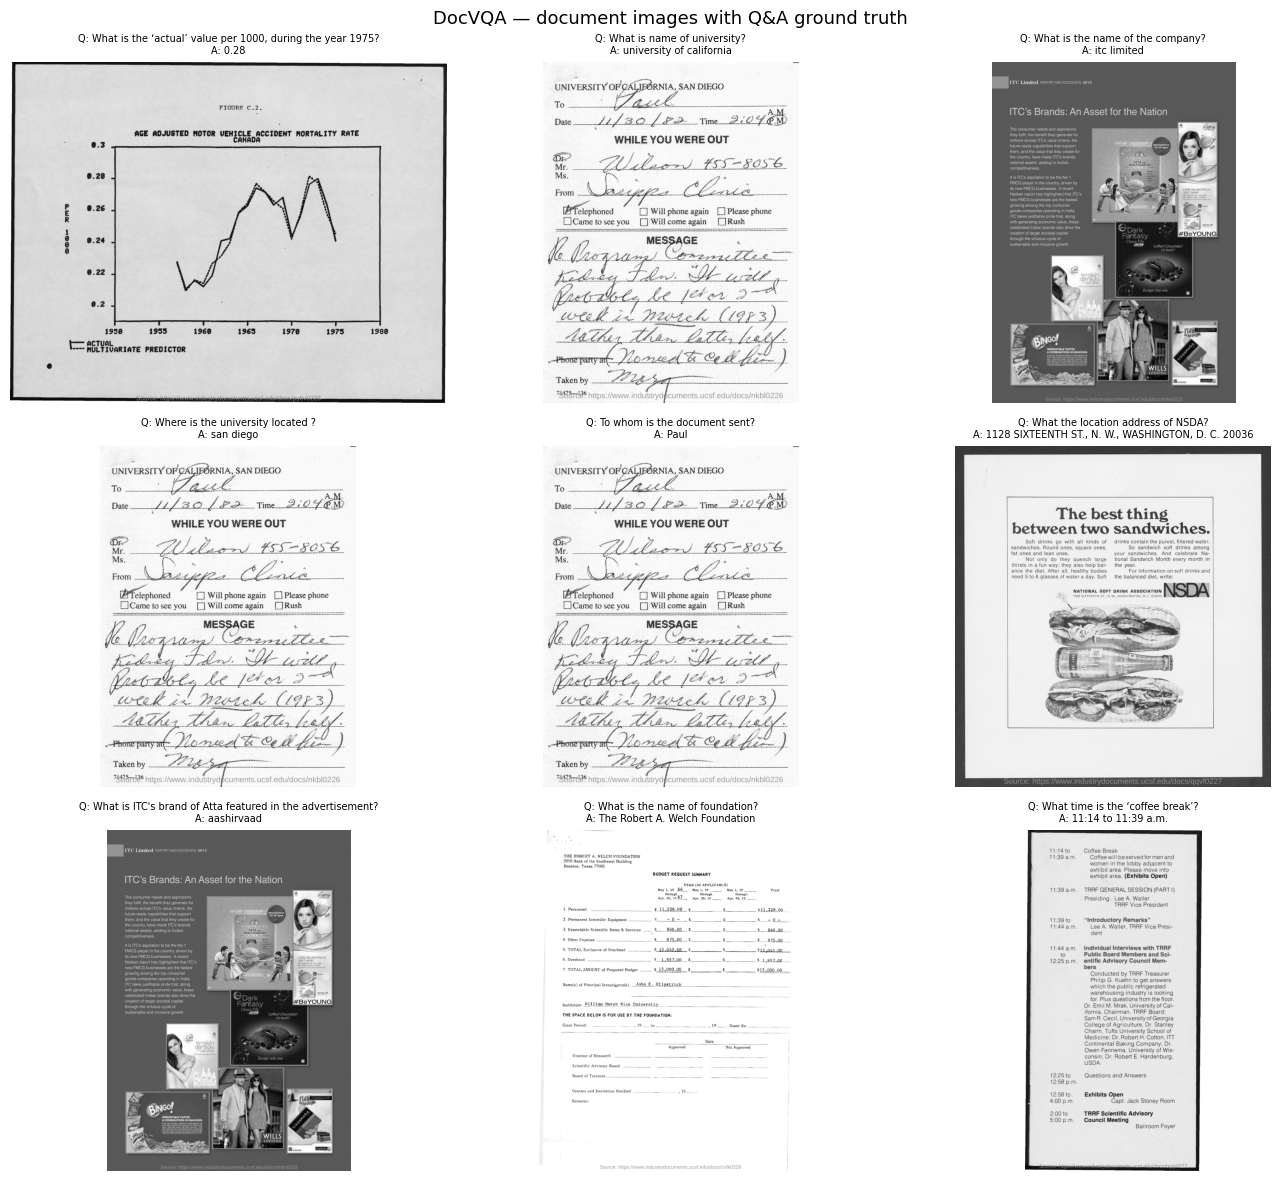

Saved.


In [14]:
# ─── CELL 5: visualise 9 samples ────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(ds[i]['image'], cmap='gray')
    # wrap long questions
    q = ds[i]['question'][:60] + "..." if len(ds[i]['question']) > 60 else ds[i]['question']
    ax.set_title(f"Q: {q}\nA: {ds[i]['answers'][0]}", fontsize=7)
    ax.axis('off')

plt.suptitle("DocVQA — document images with Q&A ground truth", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/sample_grid.png", dpi=120)
plt.show()
print("Saved.")

In [15]:
# ─── CELL 6: define complexity + save metadata ───────────────────────────
import pandas as pd

def complexity(answer):
    # simple = short answer (number/word), medium = phrase, complex = sentence
    a = answer[0] if answer else ""
    words = len(a.split())
    if words <= 2:   return 'simple'
    elif words <= 6: return 'medium'
    else:            return 'complex'

meta = []
for i in range(len(ds)):
    s = ds[i]
    meta.append({
        'id':            i,
        'question_id':   s['questionId'],
        'question':      s['question'],
        'ground_truth':  s['answers'][0] if s['answers'] else '',
        'question_type': s['question_types'][0] if s['question_types'] else 'unknown',
        'complexity':    complexity(s['answers'])
    })

df_meta = pd.DataFrame(meta)
df_meta.to_csv("results/metadata.csv", index=False)

print(df_meta['complexity'].value_counts())
print("\nQuestion types:")
print(df_meta['question_type'].value_counts().head(10))
print("\nSaved to results/metadata.csv")

complexity
simple     201
medium      92
complex      7
Name: count, dtype: int64

Question types:
question_type
table/list        85
layout            69
free_text         59
form              45
Image/Photo       24
figure/diagram    12
handwritten        3
others             3
Name: count, dtype: int64

Saved to results/metadata.csv


In [17]:
# ─── CELL 7: commit ──────────────────────────────────────────────────────
!git config --global user.email "chaitanyamhetre97@email.com"
!git config --global user.name "chaitanyamhetre"

!git add .
!git commit -m "Add notebook 01 — DocVQA data exploration and metadata"
!git push

[main 2591961] Add notebook 01 — DocVQA data exploration and metadata
 7 files changed, 305 insertions(+)
 create mode 100644 notebooks/.gitkeep
 create mode 100644 notebooks/01_data_exploration.ipynb
 create mode 100644 notebooks/02_ocr_baseline.ipynb
 create mode 100644 notebooks/03_vlm_extraction.ipynb
 create mode 100644 notebooks/04_analysis.ipynb
 create mode 100644 notebooks/results/figures/sample_grid.png
 create mode 100644 notebooks/results/metadata.csv
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (12/12), 1.07 MiB | 3.56 MiB/s, done.
Total 12 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/chaitanyamhetre/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank.git
   a38b930..2591961  main -> main
